# Lincolnshire Crop Prediction

## 01 — CROME Schema Audit

## Project objective

The purpose of this notebook is to examine the structure and quality of the 2024 and 2025 Crop Map of England data for Lincolnshire.

Before developing a machine-learning model, I will:

- inspect the available columns and data types;
- check for missing or duplicate values;
- examine the CROME land-use codes;
- validate classification probabilities and geometries;
- determine whether the same spatial cell identifiers appear in both years.

In [4]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests

## 2. Define the project paths

In [5]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

raw_data_directory = project_root / "data" / "raw"

print(f"Project root: {project_root}")
print(f"Raw data directory: {raw_data_directory}")

Project root: /Users/dafyddjones/projects/lincolnshire-crop-prediction
Raw data directory: /Users/dafyddjones/projects/lincolnshire-crop-prediction/data/raw


## 3. Define the CROME API endpoints

The 2024 and 2025 CROME datasets have separate dataset identifiers and Lincolnshire collections. These endpoints return the individual geographic features.

In [7]:
base_api_url = "https://environment.data.gov.uk/geoservices/datasets"

dataset_id_2024 = "0903079b-35a2-47de-b805-77a0cc0c57bf"
dataset_id_2025 = "04dc895b-e25d-485d-9b0c-d912a0259da8"

collection_2024 = "Crop_Map_of_England_2024_Lincolnshire"
collection_2025 = "Crop_Map_of_England_2025_Lincolnshire"

api_url_2024 = (
    f"{base_api_url}/{dataset_id_2024}/ogc/features/v1/"
    f"collections/{collection_2024}/items"
)

api_url_2025 = (
    f"{base_api_url}/{dataset_id_2025}/ogc/features/v1/"
    f"collections/{collection_2025}/items"
)

print("2024 API:", api_url_2024)
print("2025 API:", api_url_2025)

2024 API: https://environment.data.gov.uk/geoservices/datasets/0903079b-35a2-47de-b805-77a0cc0c57bf/ogc/features/v1/collections/Crop_Map_of_England_2024_Lincolnshire/items
2025 API: https://environment.data.gov.uk/geoservices/datasets/04dc895b-e25d-485d-9b0c-d912a0259da8/ogc/features/v1/collections/Crop_Map_of_England_2025_Lincolnshire/items


## 4. Test the 2024 API connection

I will initially request only 10 records. This confirms that the API is available without downloading the complete Lincolnshire dataset.

In [8]:
request_parameters = {
    "f": "json",
    "limit": 10
}

response_2024 = requests.get(
    api_url_2024,
    params=request_parameters,
    timeout=60
)

print("Status code:", response_2024.status_code)
print("Requested URL:", response_2024.url)

Status code: 200
Requested URL: https://environment.data.gov.uk/geoservices/datasets/0903079b-35a2-47de-b805-77a0cc0c57bf/ogc/features/v1/collections/Crop_Map_of_England_2024_Lincolnshire/items?f=json&limit=10


In [9]:
print("Content type:", response_2024.headers.get("Content-Type"))

data_2024 = response_2024.json()

print("Python object:", type(data_2024))
print("GeoJSON type:", data_2024.get("type"))
print("Returned features:", len(data_2024.get("features", [])))
print("Available keys:", data_2024.keys())

Content type: application/json; charset=utf-8
Python object: <class 'dict'>
GeoJSON type: FeatureCollection
Returned features: 10
Available keys: dict_keys(['type', 'features', 'totalFeatures', 'numberMatched', 'numberReturned', 'timeStamp', 'links', 'crs', 'bbox'])


In [10]:
print("Total matching records:", data_2024.get("numberMatched"))
print("Records returned:", data_2024.get("numberReturned"))
print("Coordinate reference system:", data_2024.get("crs"))

first_feature = data_2024["features"][0]

print("\nFeature ID:", first_feature.get("id"))
print("Geometry type:", first_feature["geometry"].get("type"))
print("\nFeature properties:")

pd.Series(first_feature["properties"])

Total matching records: 1679186
Records returned: 10
Coordinate reference system: {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:EPSG::4326'}}

Feature ID: Crop_Map_of_England_2024_Lincolnshire.1
Geometry type: Polygon

Feature properties:


county                    LIN
cromeid       RPA509566372483
shape_leng         239.998561
shape_area               None
lucode                   WA00
prob                    0.221
dtype: object

## 5. Convert the 2024 sample into a GeoDataFrame

A GeoDataFrame combines ordinary tabular fields with a geometry column containing the location and boundary of each CROME cell.

In [11]:
sample_2024 = gpd.GeoDataFrame.from_features(
    data_2024["features"],
    crs="EPSG:4326"
)

sample_2024

,geometry,county,cromeid,shape_leng,shape_area,lucode,prob
0,"POLYGON ((-0.35917 53.2381, -0.35948 53.23779,...",LIN,RPA509566372483,239.998561,None,WA00,0.221
1,"POLYGON ((0.34833 53.14279, 0.34773 53.1428, 0...",LIN,RPA557146363234,239.998561,None,WA00,0.282
2,"POLYGON ((0.18536 53.44301, 0.18596 53.443, 0....",LIN,RPA545266396212,239.998561,None,WA00,0.826
3,"POLYGON ((-0.4117 53.11424, -0.4123 53.11425, ...",LIN,RPA506386358661,239.998561,None,WA00,0.260
4,"POLYGON ((0.18232 53.46019, 0.18172 53.4602, 0...",LIN,RPA544966398187,239.998561,None,WA00,0.807
5,"POLYGON ((-0.68592 53.11758, -0.68652 53.11759...",LIN,RPA488026358661,239.998561,None,WA00,0.937
6,"POLYGON ((0.17918 53.45184, 0.17858 53.45185, ...",LIN,RPA544786397252,239.998908,None,WA00,0.930
7,"POLYGON ((-0.68655 53.14593, -0.68686 53.14562...",LIN,RPA487906361779,239.998561,None,WA00,0.960
8,"POLYGON ((-0.38798 53.24503, -0.38858 53.24504...",LIN,RPA507646373245,239.998561,None,WA00,0.127
9,"POLYGON ((-0.88205 53.50509, -0.88265 53.5051,...",LIN,RPA474226401547,239.998908,None,WA00,0.998


In [12]:
sample_2024.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   geometry    10 non-null     geometry
 1   county      10 non-null     str     
 2   cromeid     10 non-null     str     
 3   shape_leng  10 non-null     float64 
 4   shape_area  0 non-null      object  
 5   lucode      10 non-null     str     
 6   prob        10 non-null     float64 
dtypes: float64(2), geometry(1), object(1), str(3)
memory usage: 912.0+ bytes


## 6. Test the 2025 API connection

The same request parameters will be used so that the 2024 and 2025 sample structures can be compared consistently.

In [13]:
response_2025 = requests.get(
    api_url_2025,
    params=request_parameters,
    timeout=60
)

print("Status code:", response_2025.status_code)
print("Requested URL:", response_2025.url)
print("Content type:", response_2025.headers.get("Content-Type"))

Status code: 200
Requested URL: https://environment.data.gov.uk/geoservices/datasets/04dc895b-e25d-485d-9b0c-d912a0259da8/ogc/features/v1/collections/Crop_Map_of_England_2025_Lincolnshire/items?f=json&limit=10
Content type: application/json; charset=utf-8


In [14]:
data_2025 = response_2025.json()

print("GeoJSON type:", data_2025.get("type"))
print("Total matching records:", data_2025.get("numberMatched"))
print("Records returned:", data_2025.get("numberReturned"))

sample_2025 = gpd.GeoDataFrame.from_features(
    data_2025["features"],
    crs="EPSG:4326"
)

sample_2025.info()

GeoJSON type: FeatureCollection
Total matching records: 1679186
Records returned: 10
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  10 non-null     geometry
 1   cromeid   10 non-null     str     
 2   lucode    10 non-null     str     
 3   prob      10 non-null     float64 
 4   county    10 non-null     str     
dtypes: float64(1), geometry(1), str(3)
memory usage: 752.0 bytes


## 7. Compare the annual schemas

The core variables must be consistent across both years before the records can be joined for machine learning.

In [15]:
columns_2024 = set(sample_2024.columns)
columns_2025 = set(sample_2025.columns)

common_columns = columns_2024.intersection(columns_2025)
only_2024 = columns_2024.difference(columns_2025)
only_2025 = columns_2025.difference(columns_2024)

print("Common columns:", sorted(common_columns))
print("Only in 2024:", sorted(only_2024))
print("Only in 2025:", sorted(only_2025))

Common columns: ['county', 'cromeid', 'geometry', 'lucode', 'prob']
Only in 2024: ['shape_area', 'shape_leng']
Only in 2025: []


## 8. Check whether CROME cell identifiers are stable

Matching `cromeid` values would allow the 2024 and 2025 records to be joined directly by location.

In [16]:
ids_2024 = set(sample_2024["cromeid"])
ids_2025 = set(sample_2025["cromeid"])

matching_ids = ids_2024.intersection(ids_2025)

overlap_percentage = (
    len(matching_ids) / len(ids_2025) * 100
)

print("Unique 2024 IDs:", len(ids_2024))
print("Unique 2025 IDs:", len(ids_2025))
print("Matching IDs:", len(matching_ids))
print(f"Overlap: {overlap_percentage:.1f}%")

Unique 2024 IDs: 10
Unique 2025 IDs: 10
Matching IDs: 10
Overlap: 100.0%


## 9. Join the 2024 and 2025 samples

The annual samples will be joined using `cromeid` so that each row contains the 2024 and 2025 classification for the same location.

In [17]:
comparison_sample = sample_2024[
    ["cromeid", "lucode", "prob"]
].merge(
    sample_2025[["cromeid", "lucode", "prob"]],
    on="cromeid",
    how="inner",
    suffixes=("_2024", "_2025")
)

comparison_sample["land_use_changed"] = (
    comparison_sample["lucode_2024"]
    != comparison_sample["lucode_2025"]
)

comparison_sample

,cromeid,lucode_2024,prob_2024,lucode_2025,prob_2025,land_use_changed
0,RPA509566372483,WA00,0.221,AC63,0.393,True
1,RPA557146363234,WA00,0.282,NA01,0.202,True
2,RPA545266396212,WA00,0.826,WA00,0.365,False
3,RPA506386358661,WA00,0.260,NA01,0.284,True
4,RPA544966398187,WA00,0.807,WA00,0.495,False
5,RPA488026358661,WA00,0.937,NA01,0.274,True
6,RPA544786397252,WA00,0.930,WA00,0.510,False
7,RPA487906361779,WA00,0.960,WA00,0.650,False
8,RPA507646373245,WA00,0.127,AC66,0.831,True
9,RPA474226401547,WA00,0.998,WA00,0.915,False


In [18]:
change_counts = comparison_sample["land_use_changed"].value_counts()

change_rate = comparison_sample["land_use_changed"].mean() * 100

print(change_counts)
print(f"\nPercentage with a changed code: {change_rate:.1f}%")

land_use_changed
True     5
False    5
Name: count, dtype: int64

Percentage with a changed code: 50.0%


## 10. Define a larger spatial sample

The first ten API records were useful for checking the schema but were not representative. I will now request all available cells within a small inland bounding box in Lincolnshire.

In [19]:
audit_bbox = (
    -0.35,  # western longitude
    52.95,  # southern latitude
    -0.30,  # eastern longitude
    53.00   # northern latitude
)

spatial_request_parameters = {
    "f": "json",
    "bbox": ",".join(map(str, audit_bbox)),
    "limit": 10_000
}

spatial_request_parameters

{'f': 'json', 'bbox': '-0.35,52.95,-0.3,53.0', 'limit': 10000}

In [21]:
spatial_response_2024 = requests.get(
    api_url_2024,
    params=spatial_request_parameters,
    timeout=120
)

print("Status code:", spatial_response_2024.status_code)

spatial_response_2024.raise_for_status()

spatial_data_2024 = spatial_response_2024.json()

print("Matching records:", spatial_data_2024.get("numberMatched"))
print("Returned records:", spatial_data_2024.get("numberReturned"))

Status code: 200
Matching records: 4868
Returned records: 4868


In [22]:
spatial_response_2025 = requests.get(
    api_url_2025,
    params=spatial_request_parameters,
    timeout=120
)

print("Status code:", spatial_response_2025.status_code)

spatial_response_2025.raise_for_status()

spatial_data_2025 = spatial_response_2025.json()

print("Matching records:", spatial_data_2025.get("numberMatched"))
print("Returned records:", spatial_data_2025.get("numberReturned"))

Status code: 200
Matching records: 4868
Returned records: 4868


In [23]:
spatial_sample_2024 = gpd.GeoDataFrame.from_features(
    spatial_data_2024["features"],
    crs="EPSG:4326"
)

spatial_sample_2025 = gpd.GeoDataFrame.from_features(
    spatial_data_2025["features"],
    crs="EPSG:4326"
)

print("2024 shape:", spatial_sample_2024.shape)
print("2025 shape:", spatial_sample_2025.shape)

print("\n2024 CRS:", spatial_sample_2024.crs)
print("2025 CRS:", spatial_sample_2025.crs)

2024 shape: (4868, 7)
2025 shape: (4868, 5)

2024 CRS: EPSG:4326
2025 CRS: EPSG:4326


In [26]:
duplicates_2024 = spatial_sample_2024["cromeid"].duplicated().sum()
duplicates_2025 = spatial_sample_2025["cromeid"].duplicated().sum()

ids_2024 = set(spatial_sample_2024["cromeid"])
ids_2025 = set(spatial_sample_2025["cromeid"])

matching_ids = ids_2024.intersection(ids_2025)

overlap_percentage = (
    len(matching_ids) / len(ids_2025) * 100
)

print("Duplicate IDs in 2024:", duplicates_2024)
print("Duplicate IDs in 2025:", duplicates_2025)
print("Matching IDs:", len(matching_ids))
print(f"2025 IDs also found in 2024: {overlap_percentage:.1f}%")

Duplicate IDs in 2024: 0
Duplicate IDs in 2025: 0
Matching IDs: 4868
2025 IDs also found in 2024: 100.0%


## 11. Join the larger spatial samples

The 2024 and 2025 samples have unique, fully matching cell identifiers. They can therefore be joined using `cromeid`.

In [27]:
spatial_comparison = spatial_sample_2024[
    ["cromeid", "lucode", "prob"]
].merge(
    spatial_sample_2025[["cromeid", "lucode", "prob"]],
    on="cromeid",
    how="inner",
    suffixes=("_2024", "_2025")
)

spatial_comparison["land_use_changed"] = (
    spatial_comparison["lucode_2024"]
    != spatial_comparison["lucode_2025"]
)

print("Joined rows:", len(spatial_comparison))
print(
    "Changed classifications:",
    spatial_comparison["land_use_changed"].sum()
)

change_rate = (
    spatial_comparison["land_use_changed"].mean() * 100
)

print(f"Classification-change rate: {change_rate:.1f}%")

Joined rows: 4868
Changed classifications: 3697
Classification-change rate: 75.9%


## 12. Examine land-use-code distributions

The annual frequency of each CROME code will help identify the dominant land uses and possible differences between the two classifications.

In [28]:
code_counts_2024 = (
    spatial_comparison["lucode_2024"]
    .value_counts()
    .rename("cells_2024")
)

code_counts_2025 = (
    spatial_comparison["lucode_2025"]
    .value_counts()
    .rename("cells_2025")
)

code_comparison = pd.concat(
    [code_counts_2024, code_counts_2025],
    axis=1
).fillna(0).astype(int)

code_comparison["share_2024"] = (
    code_comparison["cells_2024"] / len(spatial_comparison)
)

code_comparison["share_2025"] = (
    code_comparison["cells_2025"] / len(spatial_comparison)
)

code_comparison.sort_values(
    "cells_2025",
    ascending=False
)

,cells_2024,cells_2025,share_2024,share_2025
AC66,1422,2254,0.292112,0.463024
CA02,0,540,0.000000,0.110929
FA01,351,294,0.072104,0.060394
AC67,349,289,0.071693,0.059367
NA01,270,266,0.055464,0.054643
PG01,482,252,0.099014,0.051767
AC17,356,155,0.073131,0.031841
LG20,210,153,0.043139,0.031430
AC01,176,146,0.036154,0.029992
AC03,158,143,0.032457,0.029376


## 13. Inspect the official land-use-code lookup files

The annual lookup spreadsheets provide the official descriptions for each CROME land-use code. I will inspect their sheet names and structures before joining them to the spatial data.

In [29]:
lookup_path_2024 = (
    raw_data_directory
    / "crome_lucode_lookup_2024.xlsx"
)

lookup_path_2025 = (
    raw_data_directory
    / "crome_lucode_lookup_2025.xlsx"
)

print("2024 file exists:", lookup_path_2024.exists())
print("2025 file exists:", lookup_path_2025.exists())

2024 file exists: True
2025 file exists: True


In [30]:
excel_file_2024 = pd.ExcelFile(lookup_path_2024)
excel_file_2025 = pd.ExcelFile(lookup_path_2025)

print("2024 sheets:", excel_file_2024.sheet_names)
print("2025 sheets:", excel_file_2025.sheet_names)

2024 sheets: ['Sheet1']
2025 sheets: ['Sheet1']


In [31]:
lookup_raw_2024 = pd.read_excel(
    lookup_path_2024,
    sheet_name="Sheet1",
    header=None
)

lookup_raw_2025 = pd.read_excel(
    lookup_path_2025,
    sheet_name="Sheet1",
    header=None
)

print("2024 lookup:")
display(lookup_raw_2024.head(10))

print("2025 lookup:")
display(lookup_raw_2025.head(10))

2024 lookup:


,0,1,2
0,Land Cover Description,LUCODE,Land Use Description
1,Cereal Crops,AC01,Spring Barley
2,NaN,AC03,Beet
3,NaN,AC04,Borage
4,NaN,AC05,Buckwheat
5,NaN,AC06,Canary Seed
6,NaN,AC07,Carrot
7,NaN,AC08,Celery
8,NaN,AC09,Chicory
9,NaN,AC10,Daffodil


2025 lookup:


,0,1,2
0,Land Cover Description,LUCODE,Land Use Description
1,Cereal Crops,AC01,Spring Barley
2,NaN,AC03,Beet
3,NaN,AC06,Canary Seed
4,NaN,AC07,Carrot
5,NaN,AC08,Celery
6,NaN,AC11,Dill
7,NaN,AC14,Hemp
8,NaN,AC15,Lettuce
9,NaN,AC17,Maize


### Clean the annual lookup tables

The first spreadsheet row contains the headers. Blank land-cover descriptions will be carried forward because the source workbook displays each category only once for a group of codes.

In [32]:
lookup_2024 = pd.read_excel(
    lookup_path_2024,
    sheet_name="Sheet1",
    header=0
)

lookup_2025 = pd.read_excel(
    lookup_path_2025,
    sheet_name="Sheet1",
    header=0
)

lookup_2024.columns = [
    "land_cover",
    "lucode",
    "land_use"
]

lookup_2025.columns = [
    "land_cover",
    "lucode",
    "land_use"
]

lookup_2024["land_cover"] = (
    lookup_2024["land_cover"].ffill()
)

lookup_2025["land_cover"] = (
    lookup_2025["land_cover"].ffill()
)

lookup_2024 = lookup_2024.dropna(
    subset=["lucode"]
)

lookup_2025 = lookup_2025.dropna(
    subset=["lucode"]
)

display(lookup_2024.head(10))
display(lookup_2025.head(10))

,land_cover,lucode,land_use
0,Cereal Crops,AC01,Spring Barley
1,Cereal Crops,AC03,Beet
2,Cereal Crops,AC04,Borage
3,Cereal Crops,AC05,Buckwheat
4,Cereal Crops,AC06,Canary Seed
5,Cereal Crops,AC07,Carrot
6,Cereal Crops,AC08,Celery
7,Cereal Crops,AC09,Chicory
8,Cereal Crops,AC10,Daffodil
9,Cereal Crops,AC11,Dill


,land_cover,lucode,land_use
0,Cereal Crops,AC01,Spring Barley
1,Cereal Crops,AC03,Beet
2,Cereal Crops,AC06,Canary Seed
3,Cereal Crops,AC07,Carrot
4,Cereal Crops,AC08,Celery
5,Cereal Crops,AC11,Dill
6,Cereal Crops,AC14,Hemp
7,Cereal Crops,AC15,Lettuce
8,Cereal Crops,AC17,Maize
9,Cereal Crops,AC19,Spring Oats


In [33]:
codes_2024 = set(lookup_2024["lucode"])
codes_2025 = set(lookup_2025["lucode"])

codes_only_2024 = sorted(
    codes_2024.difference(codes_2025)
)

codes_only_2025 = sorted(
    codes_2025.difference(codes_2024)
)

print("Lookup rows in 2024:", len(lookup_2024))
print("Lookup rows in 2025:", len(lookup_2025))

print(
    "Duplicate codes in 2024:",
    lookup_2024["lucode"].duplicated().sum()
)

print(
    "Duplicate codes in 2025:",
    lookup_2025["lucode"].duplicated().sum()
)

print("\nCodes listed only in 2024:")
print(codes_only_2024)

print("\nCodes listed only in 2025:")
print(codes_only_2025)

Lookup rows in 2024: 88
Lookup rows in 2025: 41
Duplicate codes in 2024: 0
Duplicate codes in 2025: 0

Codes listed only in 2024:
['AC00', 'AC04', 'AC05', 'AC09', 'AC10', 'AC16', 'AC18', 'AC22', 'AC23', 'AC24', 'AC26', 'AC30', 'AC35', 'AC37', 'AC38', 'AC41', 'AC45', 'AC52', 'AC54', 'AC59', 'AC60', 'AC61', 'AC62', 'AC64', 'AC71', 'AC72', 'AC76', 'AC77', 'AC81', 'AC85', 'AC88', 'AC90', 'AC92', 'AC94', 'HE02', 'LG01', 'LG02', 'LG04', 'LG06', 'LG08', 'LG09', 'LG11', 'LG13', 'LG15', 'LG16', 'LG18', 'SR01']

Codes listed only in 2025:
[]


In [34]:
lookup_comparison = lookup_2024.merge(
    lookup_2025,
    on="lucode",
    how="inner",
    suffixes=("_2024", "_2025")
)

description_changes = lookup_comparison[
    lookup_comparison["land_use_2024"]
    != lookup_comparison["land_use_2025"]
]

print(
    "Codes available in both lookups:",
    len(lookup_comparison)
)

print(
    "Codes with changed descriptions:",
    len(description_changes)
)

description_changes

Codes available in both lookups: 41
Codes with changed descriptions: 0


,land_cover_2024,lucode,land_use_2024,land_cover_2025,land_use_2025


In [35]:
code_summary = pd.concat(
    [code_counts_2024, code_counts_2025],
    axis=1
).fillna(0).astype(int).reset_index()

code_summary = code_summary.rename(
    columns={code_summary.columns[0]: "lucode"}
)

code_summary["percentage_2024"] = (
    code_summary["cells_2024"]
    / len(spatial_comparison)
    * 100
)

code_summary["percentage_2025"] = (
    code_summary["cells_2025"]
    / len(spatial_comparison)
    * 100
)

code_summary = code_summary.merge(
    lookup_2024[["lucode", "land_use"]],
    on="lucode",
    how="left"
)

code_summary = code_summary.rename(
    columns={"land_use": "land_use_description"}
)

code_summary.sort_values(
    "cells_2025",
    ascending=False
).round(2)

,lucode,cells_2024,cells_2025,percentage_2024,percentage_2025,land_use_description
0,AC66,1422,2254,29.21,46.30,Winter Wheat
19,CA02,0,540,0.00,11.09,Cover Crop
3,FA01,351,294,7.21,6.04,Fallow Land
4,AC67,349,289,7.17,5.94,Winter Oilseed
5,NA01,270,266,5.55,5.46,Non-vegetated or sparsely-vegetated Land
1,PG01,482,252,9.90,5.18,Grass
2,AC17,356,155,7.31,3.18,Maize
8,LG20,210,153,4.31,3.14,Winter Field beans
9,AC01,176,146,3.62,3.00,Spring Barley
10,AC03,158,143,3.25,2.94,Beet


## 14. Examine the most common classification transitions

In [36]:
comparison_named = spatial_comparison.merge(
    lookup_2024[["lucode", "land_use"]].rename(
        columns={
            "lucode": "lucode_2024",
            "land_use": "land_use_2024"
        }
    ),
    on="lucode_2024",
    how="left"
)

comparison_named = comparison_named.merge(
    lookup_2025[["lucode", "land_use"]].rename(
        columns={
            "lucode": "lucode_2025",
            "land_use": "land_use_2025"
        }
    ),
    on="lucode_2025",
    how="left"
)

transition_summary = (
    comparison_named[
        comparison_named["land_use_changed"]
    ]
    .groupby(
        ["land_use_2024", "land_use_2025"]
    )
    .size()
    .reset_index(name="cells")
    .sort_values("cells", ascending=False)
)

transition_summary["percentage_of_changes"] = (
    transition_summary["cells"]
    / comparison_named["land_use_changed"].sum()
    * 100
)

transition_summary.head(15).round(2)

,land_use_2024,land_use_2025,cells,percentage_of_changes
130,Winter Oilseed,Winter Wheat,326,8.82
144,Winter Wheat,Winter Oilseed,273,7.38
17,Fallow Land,Winter Wheat,209,5.65
38,Maize,Winter Wheat,208,5.63
107,Winter Barley,Winter Wheat,183,4.95
134,Winter Wheat,Fallow Land,155,4.19
116,Winter Field beans,Winter Wheat,148,4.00
18,Grass,Cover Crop,131,3.54
49,Potato,Winter Wheat,120,3.25
6,Beet,Winter Wheat,119,3.22


In [37]:
transition_summary = transition_summary.reset_index(
    drop=True
)

transition_summary.head(15).round(2)

,land_use_2024,land_use_2025,cells,percentage_of_changes
0,Winter Oilseed,Winter Wheat,326,8.82
1,Winter Wheat,Winter Oilseed,273,7.38
2,Fallow Land,Winter Wheat,209,5.65
3,Maize,Winter Wheat,208,5.63
4,Winter Barley,Winter Wheat,183,4.95
5,Winter Wheat,Fallow Land,155,4.19
6,Winter Field beans,Winter Wheat,148,4.00
7,Grass,Cover Crop,131,3.54
8,Potato,Winter Wheat,120,3.25
9,Beet,Winter Wheat,119,3.22


## 15. Check classification probabilities and missing values

In [38]:
probability_summary = pd.DataFrame({
    "2024": spatial_sample_2024["prob"].describe(),
    "2025": spatial_sample_2025["prob"].describe()
}).round(3)

display(probability_summary)

low_probability_2024 = (
    spatial_sample_2024["prob"] < 0.5
).mean() * 100

low_probability_2025 = (
    spatial_sample_2025["prob"] < 0.5
).mean() * 100

print(
    f"2024 cells below 0.5: "
    f"{low_probability_2024:.1f}%"
)

print(
    f"2025 cells below 0.5: "
    f"{low_probability_2025:.1f}%"
)

print(
    "Missing 2024 probabilities:",
    spatial_sample_2024["prob"].isna().sum()
)

print(
    "Missing 2025 probabilities:",
    spatial_sample_2025["prob"].isna().sum()
)

,2024,2025
count,4868.000,4868.000
mean,0.431,0.517
std,0.225,0.239
min,0.092,0.100
25%,0.231,0.284
50%,0.386,0.527
75%,0.609,0.742
max,0.999,1.000


2024 cells below 0.5: 62.7%
2025 cells below 0.5: 47.8%
Missing 2024 probabilities: 0
Missing 2025 probabilities: 0


## 16. Check identifiers and geometries

The final audit checks for missing identifiers, missing classifications, invalid geometries and differences between annual cell boundaries.

In [39]:
quality_checks = pd.DataFrame({
    "2024": [
        spatial_sample_2024["cromeid"].isna().sum(),
        spatial_sample_2024["lucode"].isna().sum(),
        spatial_sample_2024.geometry.isna().sum(),
        (~spatial_sample_2024.geometry.is_valid).sum(),
        spatial_sample_2024.geometry.is_empty.sum()
    ],
    "2025": [
        spatial_sample_2025["cromeid"].isna().sum(),
        spatial_sample_2025["lucode"].isna().sum(),
        spatial_sample_2025.geometry.isna().sum(),
        (~spatial_sample_2025.geometry.is_valid).sum(),
        spatial_sample_2025.geometry.is_empty.sum()
    ]
}, index=[
    "Missing CROME IDs",
    "Missing land-use codes",
    "Missing geometries",
    "Invalid geometries",
    "Empty geometries"
])

display(quality_checks)

geometry_2024 = (
    spatial_sample_2024
    .set_index("cromeid")
    .sort_index()
    .geometry
)

geometry_2025 = (
    spatial_sample_2025
    .set_index("cromeid")
    .sort_index()
    .geometry
)

matching_geometries = geometry_2024.geom_equals(
    geometry_2025
)

print(
    "Cells with matching annual geometries:",
    matching_geometries.sum()
)

print(
    "Geometry match percentage:",
    f"{matching_geometries.mean() * 100:.1f}%"
)

,2024,2025
Missing CROME IDs,0,0
Missing land-use codes,0,0
Missing geometries,0,0
Invalid geometries,0,0
Empty geometries,0,0


Cells with matching annual geometries: 4868
Geometry match percentage: 100.0%


## 17. Compare the most common land uses

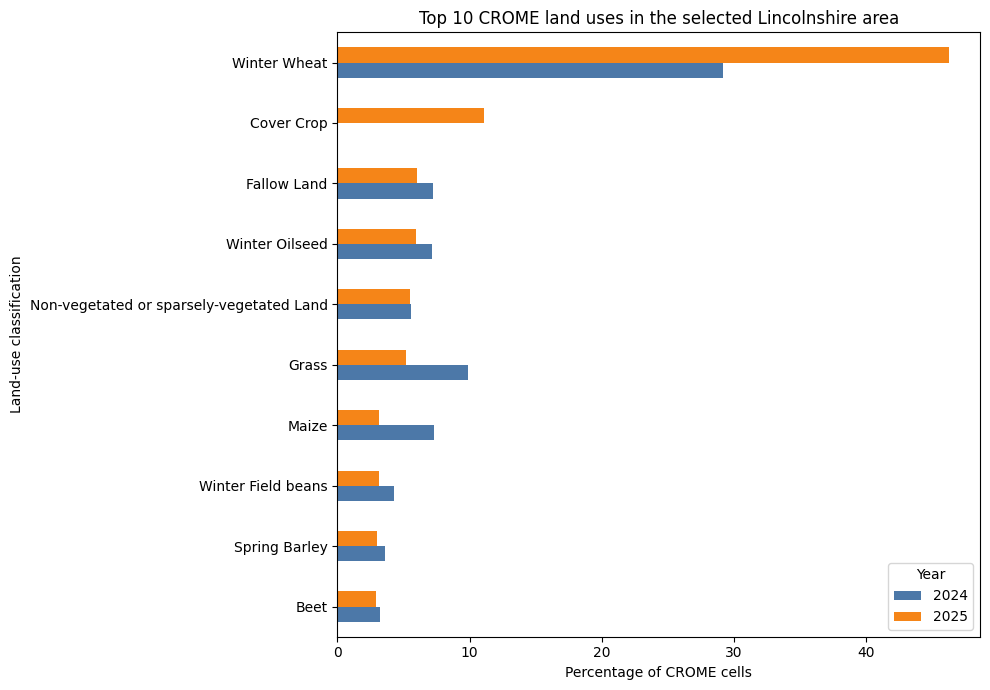

In [41]:
top_land_uses = (
    code_summary
    .sort_values("cells_2025", ascending=False)
    .head(10)
    .set_index("land_use_description")
)

plot_data = top_land_uses[
    ["percentage_2024", "percentage_2025"]
].sort_values("percentage_2025")

ax = plot_data.plot(
    kind="barh",
    figsize=(10, 7),
    color=["#4C78A8", "#F58518"]
)

ax.set_title(
    "Top 10 CROME land uses in the selected Lincolnshire area"
)

ax.set_xlabel("Percentage of CROME cells")
ax.set_ylabel("Land-use classification")
ax.legend(["2024", "2025"], title="Year")

plt.tight_layout()
plt.show()

## 18. Audit conclusion

The CROME 2024 and 2025 datasets are suitable for developing a crop-prediction project for the selected Lincolnshire area.

The spatial sample contains 4,868 cells. Every `cromeid` is unique within each year, all identifiers occur in both years, and all annual geometries match. This means that `cromeid` can be used to join the two datasets reliably.

The core fields are consistent across both years: `cromeid`, `lucode`, `prob`, `county` and `geometry`. The 2024 fields `shape_area` and `shape_leng` are not available in 2025 and will therefore not be used as model features.

The official lookup tables contain 88 codes in 2024 and 41 codes in 2025. All 2025 codes are present in the 2024 lookup, and none of the retained code descriptions changed.

Approximately 75.9% of cells received a different land-use classification in 2025. The most common transitions include winter oilseed to winter wheat, winter wheat to winter oilseed, and fallow land to winter wheat. These patterns may reflect crop rotation, but classification uncertainty must also be considered.

Classification probabilities are generally higher in 2025. The mean probability increased from 0.431 to 0.517, while the proportion below 0.5 decreased from 62.7% to 47.8%. The model-development stage should test whether probability filtering or sample weighting improves performance.

These findings support proceeding to data preparation and feature engineering. The results currently apply only to the selected Lincolnshire sample and should not be interpreted as estimates for the whole county.